# 02 - LeNet-5, VGG-11 Simplificado y Batch Normalization


Este notebook desarrolla la Tarea 1 y la Tarea 2. Se implementan CNN desde cero y luego se analiza el efecto de Batch Normalization mediante un experimento controlado.


#Verificación de GPU

In [ ]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Integración y verificación de archivo .JSON de Kaggle

In [ ]:
from google.colab import files

files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle --version

Kaggle CLI 2.0.2


# Descarga del dataset

In [5]:
!mkdir -p data/blood_cells
!kaggle datasets download -d paultimothymooney/blood-cells -p data/blood_cells
!unzip -q data/blood_cells/blood-cells.zip -d data/blood_cells

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
100% 108M/108M [00:00<00:00, 144MB/s]



In [6]:
!find data/blood_cells -maxdepth 5 -type d

data/blood_cells
data/blood_cells/dataset2-master
data/blood_cells/dataset2-master/dataset2-master
data/blood_cells/dataset2-master/dataset2-master/images
data/blood_cells/dataset2-master/dataset2-master/images/TEST
data/blood_cells/dataset2-master/dataset2-master/images/TEST/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TEST/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST/LYMPHOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST/NEUTROPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/NEUTROPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE/EOSINOPHIL

In [7]:
import os

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

print("Existe DATA_DIR:", os.path.exists(DATA_DIR))
print("Carpetas:", os.listdir(DATA_DIR))
print("Clases TRAIN:", os.listdir(os.path.join(DATA_DIR, "TRAIN")))
print("Clases TEST:", os.listdir(os.path.join(DATA_DIR, "TEST")))

Existe DATA_DIR: True
Carpetas: ['TEST', 'TRAIN', 'TEST_SIMPLE']
Clases TRAIN: ['EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'NEUTROPHIL']
Clases TEST: ['EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'NEUTROPHIL']


# Creación de estructura del trabajo

In [8]:
!mkdir -p src
!mkdir -p results/figures
!mkdir -p results/checkpoints
!mkdir -p results/metrics

# Creación de los archivos

In [9]:
%%writefile src/models.py

import torch
import torch.nn as nn


class LeNet5(nn.Module):
    """
    LeNet-5 adaptado para imágenes RGB de 64x64.
    Mantiene 2 bloques conv-pool y 3 capas fully connected.
    """

    def __init__(self, num_classes=4):
        super(LeNet5, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 13 * 13, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class LeNet5BN(nn.Module):
    """
    LeNet-5 adaptado con Batch Normalization después de cada capa convolucional.
    """

    def __init__(self, num_classes=4):
        super(LeNet5BN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 13 * 13, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class VGG11Small(nn.Module):
    """
    VGG-11 simplificado.
    Filtros reducidos a la mitad respecto a VGG-11 original.
    """

    def __init__(self, num_classes=4):
        super(VGG11Small, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class VGG11SmallBN(nn.Module):
    """
    VGG-11 simplificado con Batch Normalization después de cada capa convolucional.
    """

    def __init__(self, num_classes=4):
        super(VGG11SmallBN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Writing src/models.py


In [10]:
%%writefile src/utils.py

import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


def set_seed(seed=42):
    """
    Fija semillas para reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def count_parameters(model):
    """
    Cuenta parámetros entrenables.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_data_loaders(data_dir, batch_size=32, img_size=64, val_split=0.2, seed=42):
    """
    Carga TRAIN y TEST usando ImageFolder.
    Divide TRAIN en train/validation.
    """

    train_dir = os.path.join(data_dir, "TRAIN")
    test_dir = os.path.join(data_dir, "TEST")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    test_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

    val_size = int(len(full_train_dataset) * val_split)
    train_size = len(full_train_dataset) - val_size

    generator = torch.Generator().manual_seed(seed)

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=generator
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    class_names = full_train_dataset.classes

    return train_loader, val_loader, test_loader, class_names


def plot_training_curves(history, model_name, save_dir="results/figures"):
    """
    Guarda curvas de pérdida y accuracy.
    """

    os.makedirs(save_dir, exist_ok=True)

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title(f"Curva de pérdida - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, f"{model_name}_loss.png"), bbox_inches="tight")
    plt.close()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"Curva de accuracy - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, f"{model_name}_accuracy.png"), bbox_inches="tight")
    plt.close()

Writing src/utils.py


In [11]:
%%writefile src/train.py

import os
import time
import torch


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


def fit(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    checkpoint_dir="results/checkpoints"
):
    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    best_val_acc = 0.0

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            checkpoint_path = os.path.join(
                checkpoint_dir,
                f"{model_name}_best.pth"
            )

            torch.save({
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "epoch": epoch + 1
            }, checkpoint_path)

    return history

Writing src/train.py


# Tarea 1

## Importación de dependencias

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

from src.models import LeNet5, LeNet5BN, VGG11Small, VGG11SmallBN
from src.utils import set_seed, get_data_loaders, count_parameters, plot_training_curves
from src.train import fit, evaluate

## Lectura del dataset y parámetros

In [13]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 64
EPOCHS = 5
LR = 0.001

Dispositivo: cuda


## Creación de variables TRAIN y TEST

In [14]:
train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Creación de experimentos

In [15]:
experiments = {
    "LeNet": LeNet5(num_classes=4),
    "LeNet_BN": LeNet5BN(num_classes=4),
    "VGG11Small": VGG11Small(num_classes=4),
    "VGG11Small_BN": VGG11SmallBN(num_classes=4)
}

## Entrenamiento

In [16]:
results = []
histories = {}

criterion = nn.CrossEntropyLoss()

for model_name, model in experiments.items():
    print("=" * 80)
    print(f"Entrenando modelo: {model_name}")
    print("=" * 80)

    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)

    num_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        checkpoint_dir="results/checkpoints"
    )

    histories[model_name] = history

    plot_training_curves(
        history=history,
        model_name=model_name,
        save_dir="results/figures"
    )

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    results.append({
        "Modelo": model_name,
        "Parametros_entrenables": num_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

    print(f"Test Accuracy de {model_name}: {test_acc:.4f}")

Entrenando modelo: LeNet
Epoch [1/5] Train Loss: 1.3232 | Train Acc: 0.3376 | Val Loss: 1.2083 | Val Acc: 0.4445 | Time: 17.79s
Epoch [2/5] Train Loss: 1.1219 | Train Acc: 0.4805 | Val Loss: 1.1111 | Val Acc: 0.4741 | Time: 14.89s
Epoch [3/5] Train Loss: 0.9815 | Train Acc: 0.5447 | Val Loss: 0.9372 | Val Acc: 0.5686 | Time: 16.18s
Epoch [4/5] Train Loss: 0.9039 | Train Acc: 0.5857 | Val Loss: 0.8860 | Val Acc: 0.5917 | Time: 14.65s
Epoch [5/5] Train Loss: 0.8474 | Train Acc: 0.6204 | Val Loss: 0.8508 | Val Acc: 0.6218 | Time: 14.67s
Test Accuracy de LeNet: 0.5585
Entrenando modelo: LeNet_BN
Epoch [1/5] Train Loss: 1.0625 | Train Acc: 0.5077 | Val Loss: 1.2612 | Val Acc: 0.4450 | Time: 16.29s
Epoch [2/5] Train Loss: 0.6907 | Train Acc: 0.7050 | Val Loss: 0.9370 | Val Acc: 0.5892 | Time: 16.43s
Epoch [3/5] Train Loss: 0.4629 | Train Acc: 0.8028 | Val Loss: 1.0512 | Val Acc: 0.6444 | Time: 13.45s
Epoch [4/5] Train Loss: 0.3784 | Train Acc: 0.8371 | Val Loss: 4.6099 | Val Acc: 0.3591 | Ti

## Verificación de resultados

In [17]:
df_results = pd.DataFrame(results)
df_results

,Modelo,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,LeNet,337976,15.63,0.6218,0.5585,0.8971
1,LeNet_BN,338020,14.63,0.7408,0.4713,2.8187
2,VGG11Small,2963396,14.32,0.2557,0.2509,1.3864
3,VGG11Small_BN,2966148,14.60,0.7519,0.7053,0.5098


In [19]:
df_results.to_csv("results/metrics/tarea1_resultados.csv", index=False)

## Verificación de archivos

In [20]:
!find results -maxdepth 3 -type f

results/metrics/tarea1_resultados.csv
results/figures/VGG11Small_BN_accuracy.png
results/figures/LeNet_BN_accuracy.png
results/figures/LeNet_accuracy.png
results/figures/VGG11Small_BN_loss.png
results/figures/VGG11Small_accuracy.png
results/figures/LeNet_BN_loss.png
results/figures/LeNet_loss.png
results/figures/VGG11Small_loss.png
results/checkpoints/LeNet_best.pth
results/checkpoints/VGG11Small_BN_best.pth
results/checkpoints/LeNet_BN_best.pth
results/checkpoints/VGG11Small_best.pth


# Tarea 2

## Importación de dependencias

In [21]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from src.models import VGG11Small, VGG11SmallBN
from src.utils import set_seed, get_data_loaders, count_parameters
from src.train import fit, evaluate

## Lectura del dataset y parámetros

In [22]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 64
EPOCHS = 10
LR_BASE = 0.001

train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Dispositivo: cuda
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Entrenamiento

In [23]:
controlled_experiments = {
    "VGG11Small_sin_BN_LR_0.001": VGG11Small(num_classes=4),
    "VGG11Small_con_BN_LR_0.001": VGG11SmallBN(num_classes=4)
}

criterion = nn.CrossEntropyLoss()

controlled_results = []
controlled_histories = {}

for model_name, model in controlled_experiments.items():
    print("=" * 90)
    print(f"Experimento controlado: {model_name}")
    print("=" * 90)

    set_seed(42)

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR_BASE)

    num_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        checkpoint_dir="results/checkpoints"
    )

    controlled_histories[model_name] = history

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    controlled_results.append({
        "Modelo": model_name,
        "Batch_Normalization": "con BN" if "con_BN" in model_name else "sin BN",
        "Learning_rate": LR_BASE,
        "Parametros_entrenables": num_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

df_controlled = pd.DataFrame(controlled_results)
df_controlled

Experimento controlado: VGG11Small_sin_BN_LR_0.001
Epoch [1/10] Train Loss: 1.3874 | Train Acc: 0.2468 | Val Loss: 1.3864 | Val Acc: 0.2446 | Time: 15.51s
Epoch [2/10] Train Loss: 1.3869 | Train Acc: 0.2465 | Val Loss: 1.3865 | Val Acc: 0.2446 | Time: 15.73s
Epoch [3/10] Train Loss: 1.3866 | Train Acc: 0.2487 | Val Loss: 1.3862 | Val Acc: 0.2557 | Time: 17.99s
Epoch [4/10] Train Loss: 1.3865 | Train Acc: 0.2435 | Val Loss: 1.3866 | Val Acc: 0.2456 | Time: 15.06s
Epoch [5/10] Train Loss: 1.3866 | Train Acc: 0.2483 | Val Loss: 1.3867 | Val Acc: 0.2456 | Time: 15.87s
Epoch [6/10] Train Loss: 1.3868 | Train Acc: 0.2458 | Val Loss: 1.3864 | Val Acc: 0.2446 | Time: 16.05s
Epoch [7/10] Train Loss: 1.3866 | Train Acc: 0.2391 | Val Loss: 1.3864 | Val Acc: 0.2446 | Time: 17.16s
Epoch [8/10] Train Loss: 1.3865 | Train Acc: 0.2487 | Val Loss: 1.3864 | Val Acc: 0.2446 | Time: 14.97s
Epoch [9/10] Train Loss: 1.3863 | Train Acc: 0.2491 | Val Loss: 1.3866 | Val Acc: 0.2446 | Time: 16.52s
Epoch [10/10]

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,2963396,16.11,0.2557,0.2493,1.3863
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,2966148,16.15,0.8769,0.7941,0.6441


## Gráficas de las curvas

### Pérdida

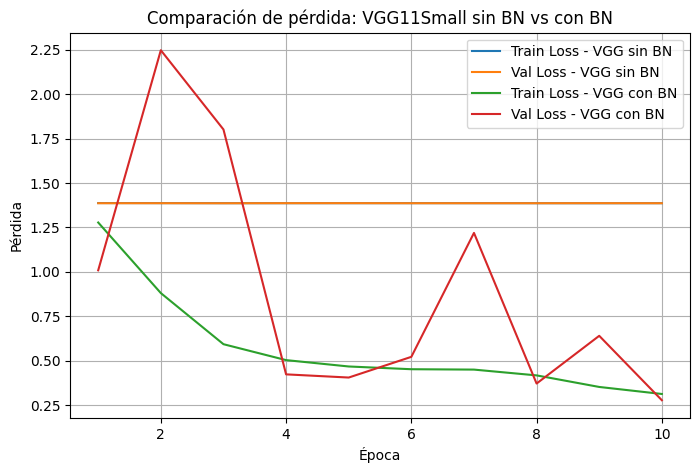

In [24]:
os.makedirs("results/figures", exist_ok=True)

hist_sin_bn = controlled_histories["VGG11Small_sin_BN_LR_0.001"]
hist_con_bn = controlled_histories["VGG11Small_con_BN_LR_0.001"]

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, hist_sin_bn["train_loss"], label="Train Loss - VGG sin BN")
plt.plot(epochs_range, hist_sin_bn["val_loss"], label="Val Loss - VGG sin BN")

plt.plot(epochs_range, hist_con_bn["train_loss"], label="Train Loss - VGG con BN")
plt.plot(epochs_range, hist_con_bn["val_loss"], label="Val Loss - VGG con BN")

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Comparación de pérdida: VGG11Small sin BN vs con BN")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_loss_vgg_bn_comparison.png", bbox_inches="tight")
plt.show()

### Accuracy

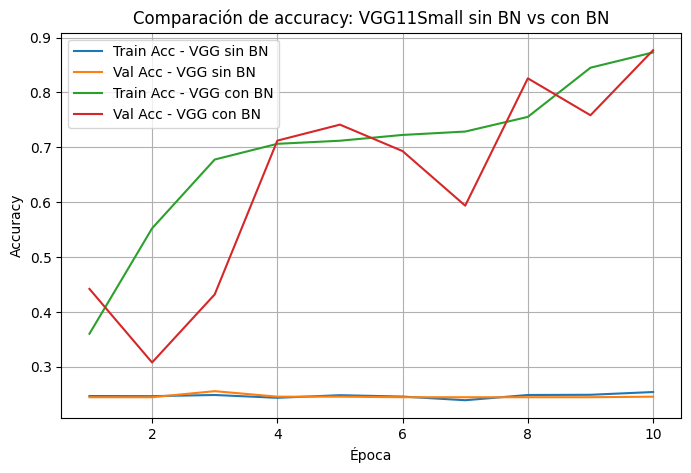

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, hist_sin_bn["train_acc"], label="Train Acc - VGG sin BN")
plt.plot(epochs_range, hist_sin_bn["val_acc"], label="Val Acc - VGG sin BN")

plt.plot(epochs_range, hist_con_bn["train_acc"], label="Train Acc - VGG con BN")
plt.plot(epochs_range, hist_con_bn["val_acc"], label="Val Acc - VGG con BN")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy: VGG11Small sin BN vs con BN")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_accuracy_vgg_bn_comparison.png", bbox_inches="tight")
plt.show()

## Cálculo de épocas hasta llegar al 80%

In [26]:
def epoch_to_reach_accuracy(acc_values, threshold=0.80):
    """
    Devuelve la primera época donde se alcanza el accuracy indicado.
    Si no lo alcanza, devuelve None.
    """
    for idx, acc in enumerate(acc_values):
        if acc >= threshold:
            return idx + 1
    return None


threshold = 0.80

convergence_summary = []

for model_name, history in controlled_histories.items():
    train_epoch_80 = epoch_to_reach_accuracy(history["train_acc"], threshold)
    val_epoch_80 = epoch_to_reach_accuracy(history["val_acc"], threshold)

    convergence_summary.append({
        "Modelo": model_name,
        "Epoca_80_train_acc": train_epoch_80 if train_epoch_80 is not None else "No alcanzó",
        "Epoca_80_val_acc": val_epoch_80 if val_epoch_80 is not None else "No alcanzó",
        "Max_train_acc": round(max(history["train_acc"]), 4),
        "Max_val_acc": round(max(history["val_acc"]), 4)
    })

df_convergence = pd.DataFrame(convergence_summary)
df_convergence

,Modelo,Epoca_80_train_acc,Epoca_80_val_acc,Max_train_acc,Max_val_acc
0,VGG11Small_sin_BN_LR_0.001,No alcanzó,No alcanzó,0.2541,0.2557
1,VGG11Small_con_BN_LR_0.001,9,8,0.8730,0.8769


## Guardar datos

In [28]:
os.makedirs("results/metrics", exist_ok=True)

df_controlled.to_csv("results/metrics/tarea2_experimento_controlado.csv", index=False)
df_convergence.to_csv("results/metrics/tarea2_convergencia_80_accuracy.csv", index=False)

## Probar learning rate más alto

In [29]:
LR_HIGH = 0.01
EPOCHS_HIGH_LR = 10

high_lr_experiments = {
    "VGG11Small_sin_BN_LR_0.01": VGG11Small(num_classes=4),
    "VGG11Small_con_BN_LR_0.01": VGG11SmallBN(num_classes=4)
}

high_lr_results = []
high_lr_histories = {}

for model_name, model in high_lr_experiments.items():
    print("=" * 90)
    print(f"Experimento LR alto: {model_name}")
    print("=" * 90)

    set_seed(42)

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR_HIGH)

    num_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS_HIGH_LR,
        checkpoint_dir="results/checkpoints"
    )

    high_lr_histories[model_name] = history

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    high_lr_results.append({
        "Modelo": model_name,
        "Batch_Normalization": "con BN" if "con_BN" in model_name else "sin BN",
        "Learning_rate": LR_HIGH,
        "Parametros_entrenables": num_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

df_high_lr = pd.DataFrame(high_lr_results)
df_high_lr

Experimento LR alto: VGG11Small_sin_BN_LR_0.01
Epoch [1/10] Train Loss: 7.1185 | Train Acc: 0.2462 | Val Loss: 1.3868 | Val Acc: 0.2446 | Time: 14.75s
Epoch [2/10] Train Loss: 1.3875 | Train Acc: 0.2429 | Val Loss: 1.3862 | Val Acc: 0.2557 | Time: 14.65s
Epoch [3/10] Train Loss: 1.3869 | Train Acc: 0.2556 | Val Loss: 1.3864 | Val Acc: 0.2557 | Time: 14.55s
Epoch [4/10] Train Loss: 1.3875 | Train Acc: 0.2517 | Val Loss: 1.3877 | Val Acc: 0.2456 | Time: 14.59s
Epoch [5/10] Train Loss: 1.3872 | Train Acc: 0.2538 | Val Loss: 1.3874 | Val Acc: 0.2456 | Time: 14.42s
Epoch [6/10] Train Loss: 1.3876 | Train Acc: 0.2473 | Val Loss: 1.3862 | Val Acc: 0.2541 | Time: 14.52s
Epoch [7/10] Train Loss: 1.3872 | Train Acc: 0.2497 | Val Loss: 1.3872 | Val Acc: 0.2456 | Time: 14.70s
Epoch [8/10] Train Loss: 1.3872 | Train Acc: 0.2445 | Val Loss: 1.3864 | Val Acc: 0.2557 | Time: 14.80s
Epoch [9/10] Train Loss: 1.3870 | Train Acc: 0.2398 | Val Loss: 1.3872 | Val Acc: 0.2446 | Time: 14.84s
Epoch [10/10] Tra

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.01,sin BN,0.01,2963396,14.65,0.2557,0.2505,1.3866
1,VGG11Small_con_BN_LR_0.01,con BN,0.01,2966148,15.10,0.3245,0.2505,1.3866


## Gráfica

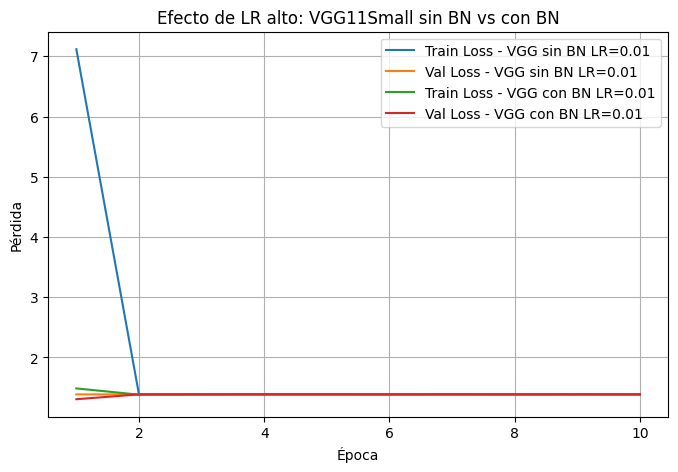

In [30]:
hist_sin_bn_high = high_lr_histories["VGG11Small_sin_BN_LR_0.01"]
hist_con_bn_high = high_lr_histories["VGG11Small_con_BN_LR_0.01"]

epochs_high_range = range(1, EPOCHS_HIGH_LR + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_high_range, hist_sin_bn_high["train_loss"], label="Train Loss - VGG sin BN LR=0.01")
plt.plot(epochs_high_range, hist_sin_bn_high["val_loss"], label="Val Loss - VGG sin BN LR=0.01")

plt.plot(epochs_high_range, hist_con_bn_high["train_loss"], label="Train Loss - VGG con BN LR=0.01")
plt.plot(epochs_high_range, hist_con_bn_high["val_loss"], label="Val Loss - VGG con BN LR=0.01")

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Efecto de LR alto: VGG11Small sin BN vs con BN")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_loss_high_lr_vgg_bn_comparison.png", bbox_inches="tight")
plt.show()

In [31]:
df_high_lr.to_csv("results/metrics/tarea2_experimento_lr_alto.csv", index=False)
df_high_lr

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.01,sin BN,0.01,2963396,14.65,0.2557,0.2505,1.3866
1,VGG11Small_con_BN_LR_0.01,con BN,0.01,2966148,15.10,0.3245,0.2505,1.3866


## Guardar tabla final

In [32]:
df_tarea2_final = pd.concat([df_controlled, df_high_lr], ignore_index=True)
df_tarea2_final.to_csv("results/metrics/tarea2_resultados_finales.csv", index=False)
df_tarea2_final

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,2963396,16.11,0.2557,0.2493,1.3863
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,2966148,16.15,0.8769,0.7941,0.6441
2,VGG11Small_sin_BN_LR_0.01,sin BN,0.010,2963396,14.65,0.2557,0.2505,1.3866
3,VGG11Small_con_BN_LR_0.01,con BN,0.010,2966148,15.10,0.3245,0.2505,1.3866


# Cierre del notebook

Los archivos principales generados por este notebook son las curvas de entrenamiento en `results/figures/`, los checkpoints en `results/checkpoints/` y las tablas de métricas en `results/metrics/`. Estos resultados se usan directamente en el informe técnico.
